In [65]:
import pandas as pd
df = pd.read_csv("datos_tratados.csv")
print("Columnas originales:", df.columns.tolist())
df = df.drop('customerID', axis=1)

Columnas originales: ['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total', 'Daily']


In [66]:
print("Columnas originales:", df.columns.tolist())

Columnas originales: ['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total', 'Daily']


In [67]:
# nulls
df['Total'] = df['Total'].fillna(df['Total'].median())
print("Nulls después de imputación inicial:", df.isnull().sum().sum())

Nulls después de imputación inicial: 0


In [68]:
#Analisis
desc = df.describe()
print("Análisis descriptivo:\n", desc)

Análisis descriptivo:
              Churn  SeniorCitizen      Partner   Dependents       tenure  \
count  7043.000000    7043.000000  7043.000000  7043.000000  7043.000000   
mean      0.265370       0.162147     0.483033     0.299588    32.371149   
std       0.441561       0.368612     0.499748     0.458110    24.559481   
min       0.000000       0.000000     0.000000     0.000000     0.000000   
25%       0.000000       0.000000     0.000000     0.000000     9.000000   
50%       0.000000       0.000000     0.000000     0.000000    29.000000   
75%       1.000000       0.000000     1.000000     1.000000    55.000000   
max       1.000000       1.000000     1.000000     1.000000    72.000000   

       PhoneService  MultipleLines  OnlineSecurity  OnlineBackup  \
count   7043.000000    7043.000000     7043.000000   7043.000000   
mean       0.903166       0.421837        0.286668      0.344881   
std        0.295752       0.493888        0.452237      0.475363   
min        0.000000 

In [69]:
# Ajuste de columnas numéricas
num_cols = df.select_dtypes(include=["float64", "int64"]).drop("Churn", axis=1)
num_cols = num_cols.fillna(num_cols.median())
import statsmodels.api as sm
model_desc = sm.OLS(df["Churn"], sm.add_constant(num_cols)).fit()
print(model_desc.summary())

                            OLS Regression Results                            
Dep. Variable:                  Churn   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     175.3
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:51:50   Log-Likelihood:                -3116.2
No. Observations:                7043   AIC:                             6264.
Df Residuals:                    7027   BIC:                             6374.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.2045      0.022  

In [71]:
#Z_score
z_scores = np.abs(stats.zscore(df.select_dtypes(include=["float64", "int64"])))
df = df[(z_scores < 3).all(axis=1)]
print("Forma con outliners:", df.shape)

Forma con outliners: (6361, 21)


In [72]:
print("Forma del Dataframe al eliminar columnas:", df.shape)
df.head()

Forma del Dataframe al eliminar columnas: (6361, 21)


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Daily
0,0.0,female,0.0,1.0,1.0,9.0,1.0,0.0,dsl,0.0,...,0.0,1.0,1.0,0.0,one_year,1.0,mailed_check,65.6,593.30,2.186667
1,0.0,male,0.0,0.0,0.0,9.0,1.0,1.0,dsl,0.0,...,0.0,0.0,0.0,1.0,month-to-month,0.0,mailed_check,59.9,542.40,1.996667
2,1.0,male,0.0,0.0,0.0,4.0,1.0,0.0,fiber_optic,0.0,...,1.0,0.0,0.0,0.0,month-to-month,1.0,electronic_check,73.9,280.85,2.463333
3,1.0,male,1.0,1.0,0.0,13.0,1.0,0.0,fiber_optic,0.0,...,1.0,0.0,1.0,1.0,month-to-month,1.0,electronic_check,98.0,1237.85,3.266667
4,1.0,female,1.0,1.0,0.0,3.0,1.0,0.0,fiber_optic,0.0,...,0.0,1.0,1.0,0.0,month-to-month,1.0,mailed_check,83.9,267.40,2.796667


In [73]:
# OneHotEncoder
categorical_cols = ["gender", "InternetService", "Contract", "PaymentMethod"]
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))
df = pd.concat([df.drop(categorical_cols, axis=1).reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
print("Forma después de OneHotEncoder:", df.shape)

Forma después de OneHotEncoder: (6361, 25)


In [74]:
#VIF para multicolinealidad
X_vif = df.select_dtypes(include=["float64", "int64"]).drop("Churn", axis=1)
X_vif = X_vif.fillna(X_vif.median())
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print("VIF:\n", vif_data)

# Si VIF > 10
if "Daily" in df.columns and vif_data[vif_data["feature"] == "Daily"]["VIF"].values[0] > 10:
    df = df.drop("Daily", axis=1)
df.head()

VIF:
                                   feature          VIF
0                           SeniorCitizen     1.155621
1                                 Partner     1.471307
2                              Dependents     1.387870
3                                  tenure     7.868715
4                            PhoneService  1924.329794
5                           MultipleLines     7.192918
6                          OnlineSecurity     6.152773
7                            OnlineBackup     6.665019
8                        DeviceProtection     6.805900
9                             TechSupport     6.215532
10                            StreamingTV    23.585063
11                        StreamingMovies    23.649995
12                       PaperlessBilling     1.220218
13                                Monthly          inf
14                                  Total    11.350591
15                                  Daily          inf
16                            gender_male     1.002672
17  

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Monthly,Total,gender_male,InternetService_fiber_optic,InternetService_no,Contract_one_year,Contract_two_year,PaymentMethod_credit_card_(automatic),PaymentMethod_electronic_check,PaymentMethod_mailed_check
0,0.0,0.0,1.0,1.0,9.0,1.0,0.0,0.0,1.0,0.0,...,65.6,593.30,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,9.0,1.0,1.0,0.0,0.0,0.0,...,59.9,542.40,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,...,73.9,280.85,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,1.0,1.0,0.0,13.0,1.0,0.0,0.0,1.0,1.0,...,98.0,1237.85,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,1.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,...,83.9,267.40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [76]:
# proporción de clases
# desbalanceo
class_proportion = df["Churn"].value_counts(normalize=True)
print("Proporción de clases:\n", class_proportion)
#Prueba de distribución
print("Prueba KS para normalidad de Antiguedad:", stats.kstest(df["tenure"], "norm"))

Proporción de clases:
 Churn
0.0    0.732904
1.0    0.267096
Name: proportion, dtype: float64
Prueba KS para normalidad de Antiguedad: KstestResult(statistic=np.float64(0.8885845638543676), pvalue=np.float64(0.0), statistic_location=np.float64(2.0), statistic_sign=np.int8(-1))


In [79]:
# si hay desbalance significativo
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

if class_proportion[0] / class_proportion[1] > 2:
    # otras técnicas
    smote = SMOTE(random_state=42)
    ros = RandomOverSampler(random_state=42)
    rus = RandomUnderSampler(random_state=42)
    print("Técnica de balanceo listas:")

Técnica de balanceo listas:


In [82]:
#Normalización/estandarización
from sklearn.preprocessing import MinMaxScaler, StandardScaler
numerical_cols = ["tenure", "Monthly", "Total"]
scaler_std = StandardScaler()
schaler_minmax = MinMaxScaler()

Corrrelacion y seleccion de variabkes

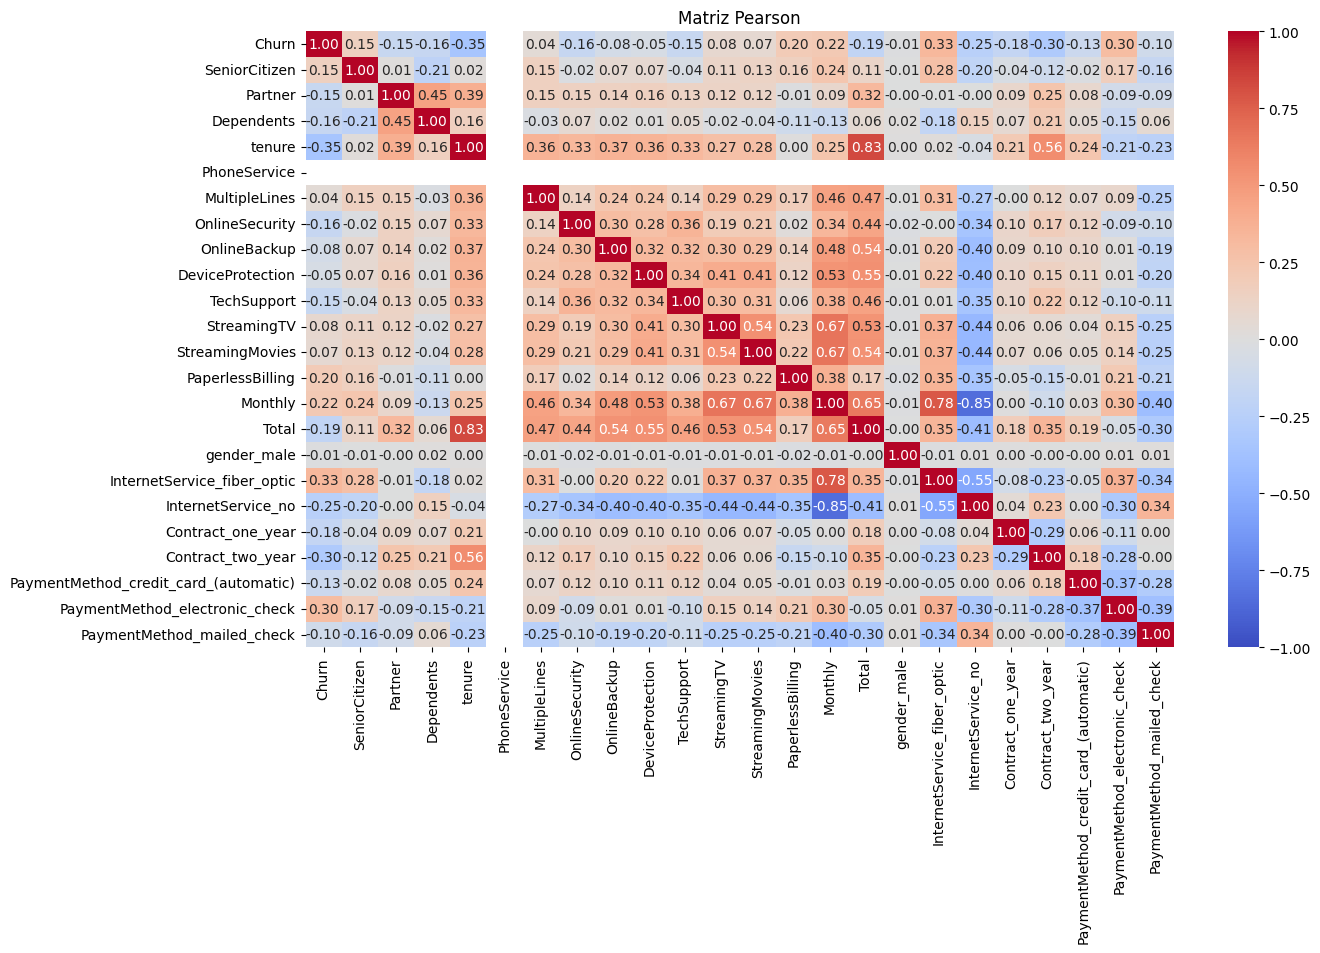

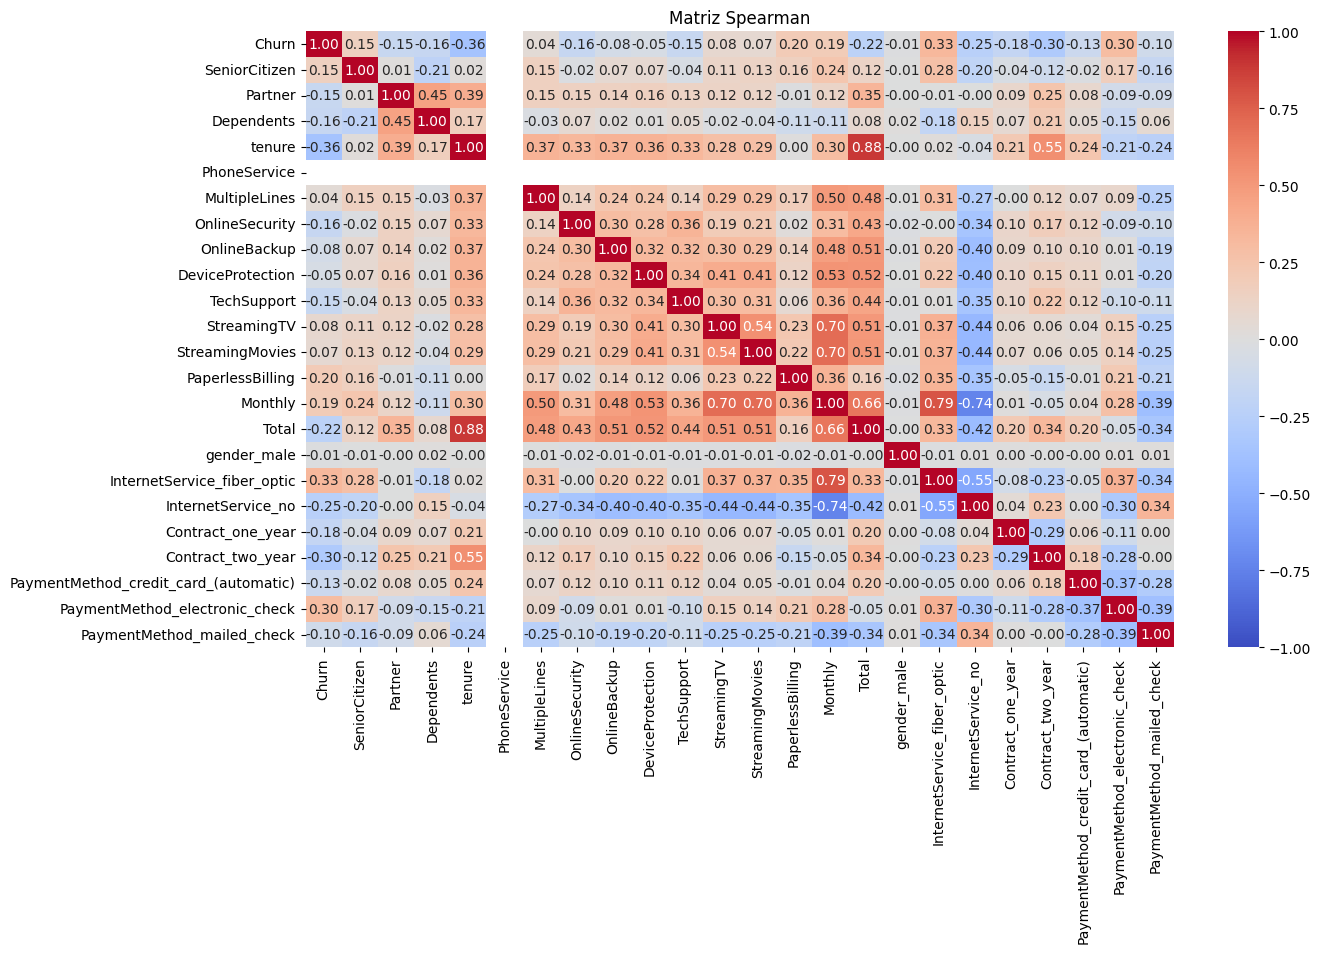

Correlaciones con Evasion (Pearson):
 Churn                                    1.000000
InternetService_fiber_optic              0.334166
PaymentMethod_electronic_check           0.303610
Monthly                                  0.216816
PaperlessBilling                         0.196368
SeniorCitizen                            0.148802
StreamingTV                              0.075438
StreamingMovies                          0.070099
MultipleLines                            0.040207
gender_male                             -0.011212
DeviceProtection                        -0.052363
OnlineBackup                            -0.075275
PaymentMethod_mailed_check              -0.096563
PaymentMethod_credit_card_(automatic)   -0.131786
TechSupport                             -0.148461
Partner                                 -0.154692
OnlineSecurity                          -0.157679
Dependents                              -0.159481
Contract_one_year                       -0.177212
Total       

In [84]:
# Matriz de correlación para variables numéricas
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# lineal
num_df = df.select_dtypes(include=["float64", "int64"])
corr_matrix = num_df.corr(method="pearson")
corr_spearman = num_df.corr(method="spearman")
plt.figure(figsize=(14, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz Pearson")
plt.show()
plt.figure(figsize=(14, 8))
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz Spearman")
plt.show()
print("Correlaciones con Evasion (Pearson):\n", corr_matrix["Churn"].sort_values(ascending=False))


for col in numerical_cols:
    corr, pval = stats.pearsonr(df[col], df["Churn"])
    print(f"Correlación {col} vs Evasion: {corr}, p-value: {pval}")

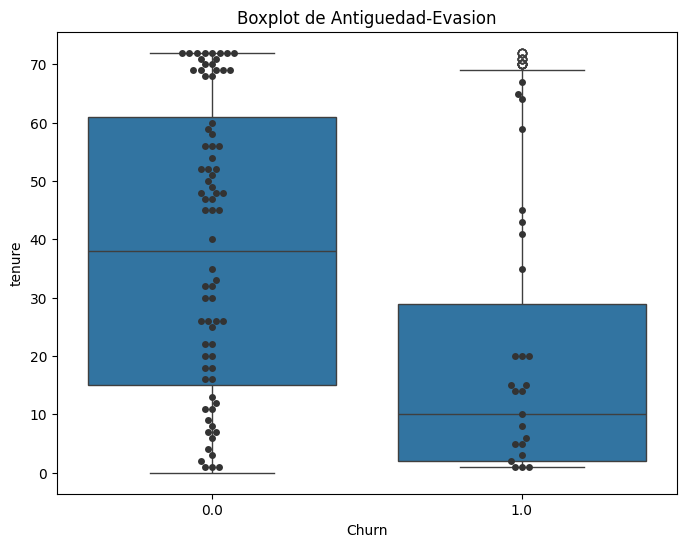

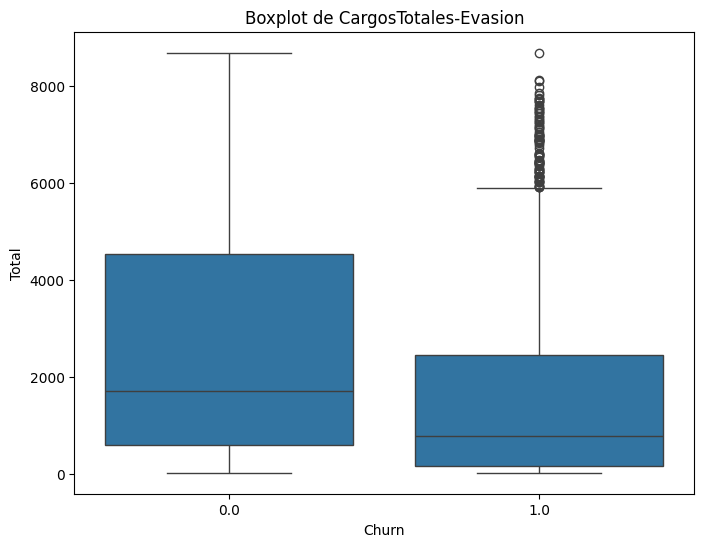

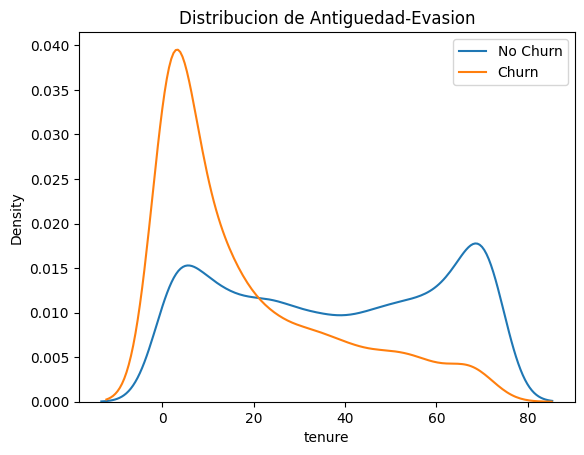

In [88]:
#Otras variables vs cancelación - Histogramas y boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x="Churn", y="tenure", data=df)
sns.swarmplot(x="Churn", y="tenure", data=df.sample(100), color=".2")
plt.title('Boxplot de Antiguedad-Evasion')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x="Churn", y="Total", data=df)
plt.title('Boxplot de CargosTotales-Evasion')
plt.show()

# Distribucion
sns.kdeplot(df[df["Churn"]==0]["tenure"], label='No Churn')
sns.kdeplot(df[df["Churn"]==1]["tenure"], label='Churn')
plt.title('Distribucion de Antiguedad-Evasion')
plt.legend()
plt.show()

In [90]:
#Modelo predictivo
from sklearn.model_selection import train_test_split
X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Forma de train/test:", X_train.shape, X_test.shape)

Forma de train/test: (4452, 23) (1909, 23)


In [92]:
# balanceo
if class_proportion[0] / class_proportion[1] > 2:
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
    X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
    #comparar
    X_train_bal, y_train_bal = X_train_smote, y_train_smote
    print("Forma de train después de SMOTE:", X_train_bal.shape)
else:
    X_train_bal, y_train_bal = X_train, y_train

Forma de train después de SMOTE: (6526, 23)


In [94]:
# 2 modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

X_train_scaled = scaler_std.fit_transform(X_train_bal)
X_test_scaled = scaler_std.transform(X_test)

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train_bal)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_bal, y_train_bal)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_bal)

KNeighborsClassifier()

In [96]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
X_train_const = sm.add_constant(X_train_bal)
lin_reg = sm.OLS(y_train_bal, X_train_const).fit()
X_test_const = sm.add_constant(X_test)
y_pred_lin = (lin_reg.predict(X_test_const) > 0.5).astype(int)
print("AUC lil base:", roc_auc_score(y_test, lin_reg.predict(X_test_const)))

AUC lil base: 0.8587709708615399


LR - Train Report:
               precision    recall  f1-score   support

         0.0       0.80      0.73      0.77      3263
         1.0       0.75      0.82      0.78      3263

    accuracy                           0.78      6526
   macro avg       0.78      0.78      0.77      6526
weighted avg       0.78      0.78      0.77      6526

LR - Test Report:
               precision    recall  f1-score   support

         0.0       0.92      0.72      0.80      1399
         1.0       0.51      0.83      0.63       510

    accuracy                           0.74      1909
   macro avg       0.72      0.77      0.72      1909
weighted avg       0.81      0.74      0.76      1909

LR - AUC Test: 0.8635769246941092


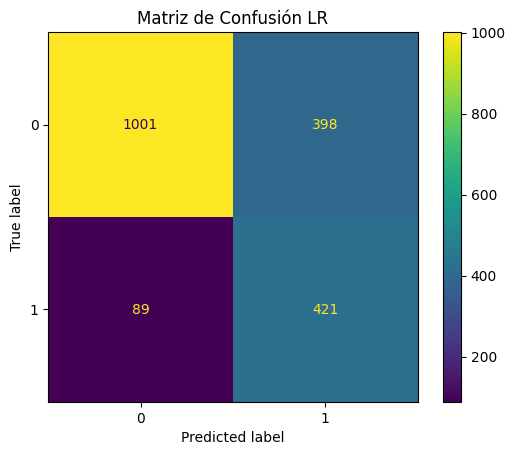

LR CV F1-macro: 0.7732287438227718
RF - Train Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3263
         1.0       1.00      1.00      1.00      3263

    accuracy                           1.00      6526
   macro avg       1.00      1.00      1.00      6526
weighted avg       1.00      1.00      1.00      6526

RF - Test Report:
               precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1399
         1.0       0.66      0.58      0.62       510

    accuracy                           0.81      1909
   macro avg       0.76      0.74      0.75      1909
weighted avg       0.80      0.81      0.81      1909

RF - AUC Test: 0.8461590211495605


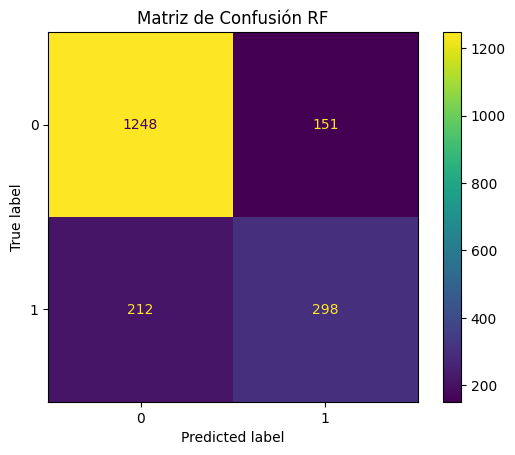

RF CV F1-macro: 0.8237351875901406
KNN - Train Report:
               precision    recall  f1-score   support

         0.0       0.94      0.76      0.84      3263
         1.0       0.80      0.95      0.87      3263

    accuracy                           0.85      6526
   macro avg       0.87      0.85      0.85      6526
weighted avg       0.87      0.85      0.85      6526

KNN - Test Report:
               precision    recall  f1-score   support

         0.0       0.89      0.67      0.76      1399
         1.0       0.46      0.76      0.57       510

    accuracy                           0.70      1909
   macro avg       0.67      0.72      0.67      1909
weighted avg       0.77      0.70      0.71      1909

KNN - AUC Test: 0.7714971478226744


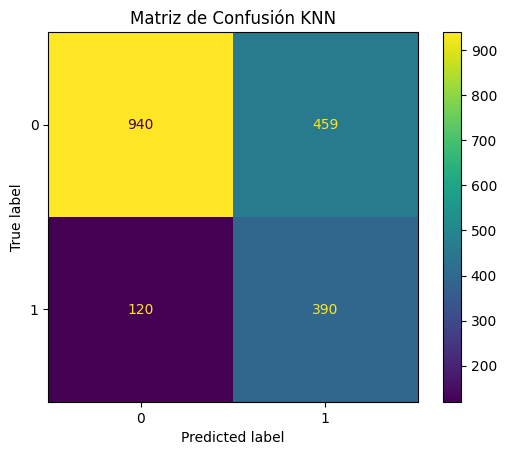

KNN CV F1-macro: 0.7776293924615818


In [98]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

models = {'LR': lr, 'RF': rf, 'KNN': knn}
for name, model in models.items():
    if name in ['LR', 'KNN']:
        y_pred = model.predict(X_test_scaled)
        y_pred_train = model.predict(X_train_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train_bal)
        y_proba = model.predict_proba(X_test)[:,1]

    print(f"{name} - Train Report:\n", classification_report(y_train_bal, y_pred_train))
    print(f"{name} - Test Report:\n", classification_report(y_test, y_pred))
    print(f"{name} - AUC Test:", roc_auc_score(y_test, y_proba))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f'Matriz de Confusión {name}')
    plt.show()

    cv_scores = cross_val_score(model, X_train_scaled if name in ['LR', 'KNN'] else X_train_bal, y_train_bal, cv=5, scoring='f1_macro')
    print(f"{name} CV F1-macro:", cv_scores.mean())

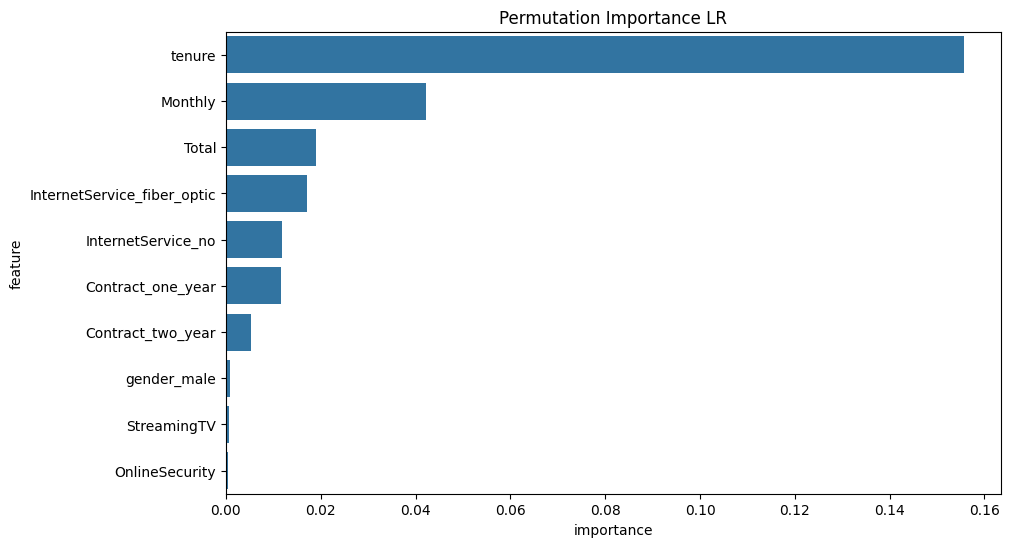

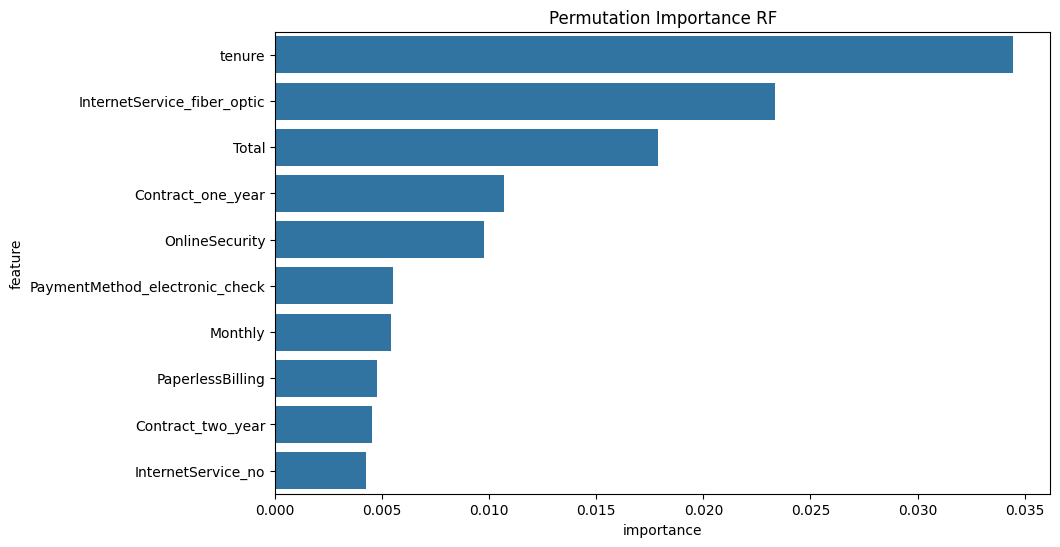

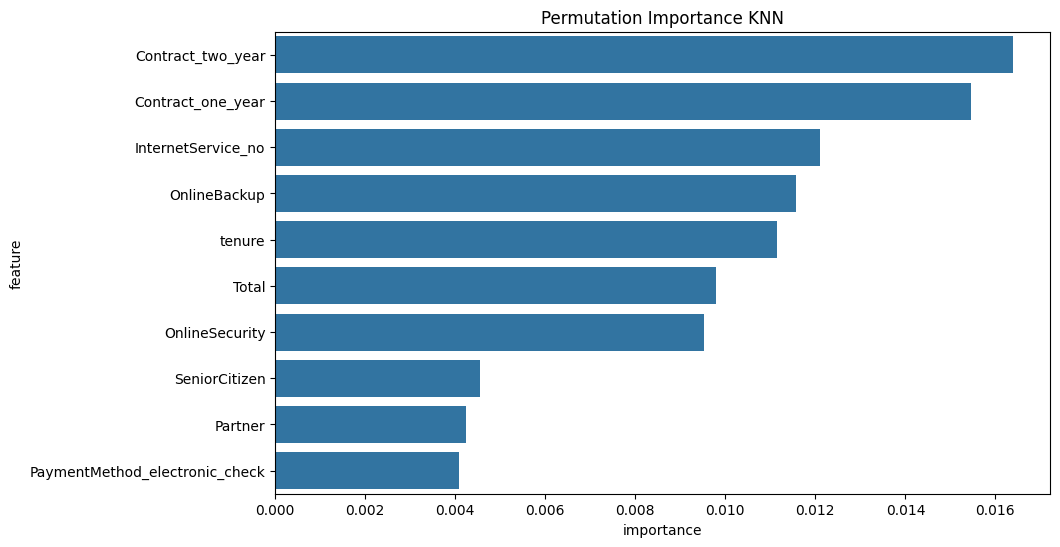

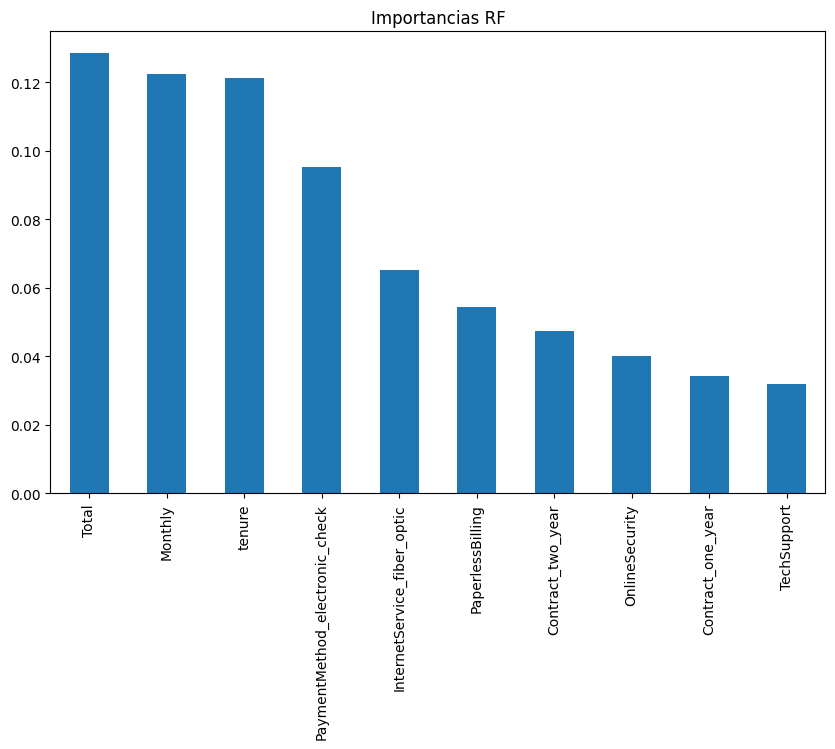

In [100]:
# Analisis
from sklearn.inspection import permutation_importance

for name, model in models.items():
    if name in ['LR', 'KNN']:
        perm_imp = permutation_importance(model, X_test_scaled, y_test, n_repeats=10, random_state=42)
    else:
        perm_imp = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
    imp_df = pd.DataFrame({'feature': X.columns, 'importance': perm_imp.importances_mean}).sort_values('importance', ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=imp_df.head(10))
    plt.title(f'Permutation Importance {name}')
    plt.show()


importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances_rf.head(10).plot(kind='bar')
plt.title('Importancias RF')
plt.show()

INFORME FINAL

Las cancelaciones de los clientes responden directamente a factores clave como el **tiempo que llevan siendo clientes (tenure)**, el **costo de sus servicios (Monthly y Total)** y los **tipos de servicios que utilizan (InternetService_fiber_optic, OnlineSecurity, TechSupport)**.

Nuestros análisis han demostrado consistentemente que los **clientes con menor antigüedad (`tenure`)** tienen una probabilidad significativamente mayor de cancelar su servicio. Esto sugiere que las personas nuevas tienden a una mayor evasión, posiblemente porque la marca no ha logrado generar una identidad sólida o una fidelización temprana con este segmento de clientes.

Además, los **precios altos (`Monthly` y `Total`)** son un factor crítico, especialmente cuando se combinan con **contratos de corta duración (mes a mes)** o la falta de **servicios de seguridad en línea y soporte técnico**. Los clientes que tienen un **servicio de internet de fibra óptica** también muestran una mayor propensión a la cancelación.

Para combatir la evasión, la empresa podría implementar las siguientes estrategias:

*   **Programas de Fidelización para Clientes Nuevos:** Ofrecer descuentos especiales, servicios premium gratuitos durante un periodo inicial o beneficios adicionales en los primeros años podría ayudar a establecer una relación más sólida y aumentar la `tenure` de los nuevos clientes.
*   **Revisión de Precios para Clientes de Contrato Corto:** Analizar la estructura de precios para clientes con contratos mes a mes, o considerar incentivos para que opten por contratos de mayor duración.
*   **Mejorar la Oferta de Servicios:** Fortalecer la percepción de valor en los servicios de seguridad en línea y soporte técnico, así como comunicar claramente los beneficios de estos, podría reducir la tasa de cancelación entre los usuarios de servicios de internet más avanzados.
*   **Análisis Segmentado:** Realizar análisis más profundos en los segmentos identificados como de alto riesgo (ej. clientes con fibra óptica y altos cargos mensuales) para entender sus necesidades específicas y desarrollar ofertas personalizadas.